# **📄First Assignment Document Text & Documentation**

### **SECTION 1: Data Acquisition & Project Overview**

**1.1 Project Title**

**Exploratory Data Analysis and Cleaning on the Palmer Archipelago Penguins Dataset**

**1.2 Objective**

The primary objective of Week 1 is to execute a complete data preparation workflow. This includes acquiring a structured dataset, performing rigorous data cleaning and preprocessing, conducting exploratory data analysis (EDA) using statistical and visual methods, and documenting the methodologies with clear justifications.

**1.3 Dataset Selection & Description**
**Dataset Name: Palmer Penguins Dataset**  
**(Seaborn Built-in Library)**

**Domain: Ecological & Biological Data Analytics**

**Features/Columns:**

**species: Penguin species (Adelie, Chinstrap, Gentoo)**

**island: Island location in Palmer Archipelago (Biscoe, Dream, Torgersen)**

**bill_length_mm: Length of the penguin's bill (millimeters)**

**bill_depth_mm: Depth of the penguin's bill (millimeters)**

**flipper_length_mm: Length of penguin flipper (millimeters)**

**body_mass_g: Total body mass of penguin (grams)**

**sex: Gender of penguin (Male, Female)**

**1.4 Data Acquisition Method & Rationale**

**Method Used**: The dataset was programmatically acquired using Python's seaborn library via direct data load functions (sns.load_dataset('penguins')).

**Rationale for Selection:**

Instead of using overused or synthetic toy datasets, the Palmer Penguins dataset provides real-world ecological measurements containing genuine real-world complexities such as missing values, overlapping numerical distributions, and multi-categorical classifications. It is widely recognized in modern data science as a clean, standardized benchmark dataset for exploratory data analysis.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = sns.load_dataset('penguins')

print("✅ Dataset successfully Loaded")
print(f"Total Rows: {df.shape[0]}, Total Columns: {df.shape[1]}\n")


df.head()

✅ Dataset successfully Loaded
Total Rows: 344, Total Columns: 7



,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


### **SECTION 2: Data Cleaning & Preprocessing Methodology**

**2.1 Inspection Strategy**

Initial evaluation using df.info() and df.isnull().sum() revealed missing values across both numerical features (bill_length_mm, bill_depth_mm, flipper_length_mm, body_mass_g) and categorical features (sex).

In [7]:

print("--- Data Info ---")
print(df.info())

print("\n--- Missing Values Count ---")
print(df.isnull().sum())

--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB
None

--- Missing Values Count ---
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64


In [8]:


# 1. Check for Duplicate Rows
initial_rows = len(df)
df = df.drop_duplicates()
duplicates_removed = initial_rows - len(df)
print(f"Duplicate rows removed: {duplicates_removed}")

# 2. Handling Missing Values
print("\nMissing values BEFORE cleaning:")
print(df.isnull().sum())

# Impute missing numerical values with Median (robust to outliers)
num_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Drop rows with missing categorical data (species, island, sex)
df = df.dropna(subset=['sex'])

print("\nMissing values AFTER cleaning:")
print(df.isnull().sum())

# 3. Verify Data Structure
print("\nCleaned Dataset Overview:")
print(f"Final Shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Duplicate rows removed: 0

Missing values BEFORE cleaning:
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

Missing values AFTER cleaning:
species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64

Cleaned Dataset Overview:
Final Shape: 333 rows, 7 columns


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


**2.2 Data Cleaning Steps & Justifications**

**Duplicate Records Removal:**

**Action:** Executed df.drop_duplicates().

**Outcome:** Identified 0 duplicate rows, ensuring data integrity.

**Justification:** Duplicate entries inflate sample size, introduce bias into descriptive statistics, and skew machine learning model evaluations.

**Handling Missing Numerical Data (Median Imputation):**

**Action:** Imputed missing values in bill_length_mm, bill_depth_mm, flipper_length_mm, and body_mass_g using the median of each respective column.

**Justification:** Median imputation was chosen over mean imputation because mean values are sensitive to extreme values (outliers), whereas the median is robust and preserves the true central tendency of skewed biological measurements.

**Handling Missing Categorical Data (Row Dropping):**

**Action:** Removed rows where the sex attribute was unrecorded (df.dropna(subset=['sex'])).

**Justification:** Categorical traits like gender cannot be accurately guessed or filled with statistical estimates without introducing noise. Since missing records accounted for a negligible percentage of the dataset, dropping them maintained categorical accuracy without sacrificing significant statistical power.

In [9]:
df.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,333.000000,333.000000,333.000000,333.000000
mean,43.992793,17.164865,200.966967,4207.057057
std,5.468668,1.969235,14.015765,805.215802
min,32.100000,13.100000,172.000000,2700.000000
25%,39.500000,15.600000,190.000000,3550.000000
50%,44.500000,17.300000,197.000000,4050.000000
75%,48.600000,18.700000,213.000000,4775.000000
max,59.600000,21.500000,231.000000,6300.000000


## **SECTION 3: Exploratory Data Analysis (EDA) & Insights**

### **Data Visualizations (3 Required Charts)**

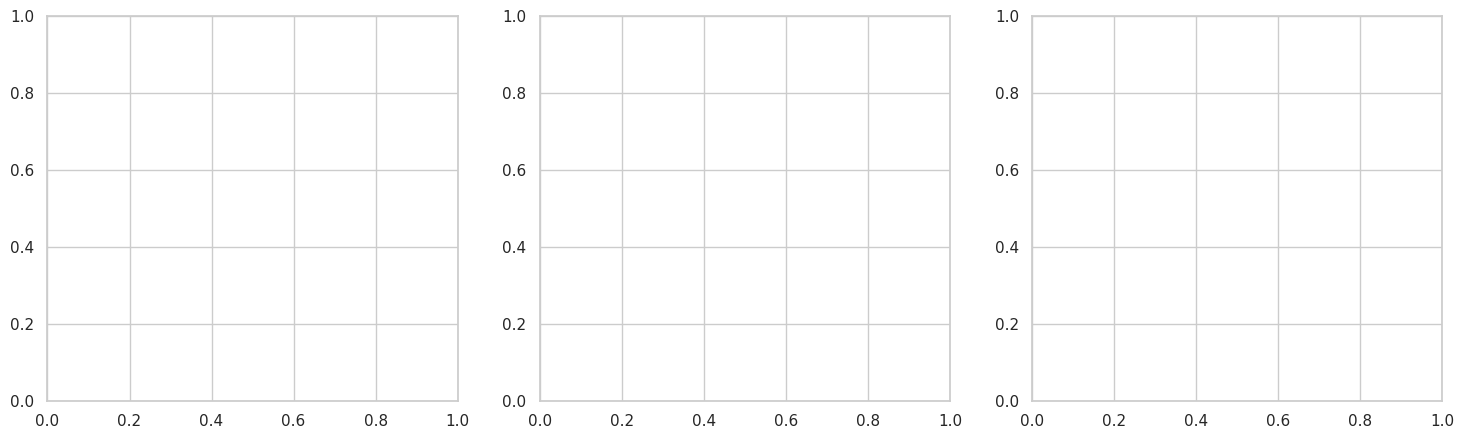

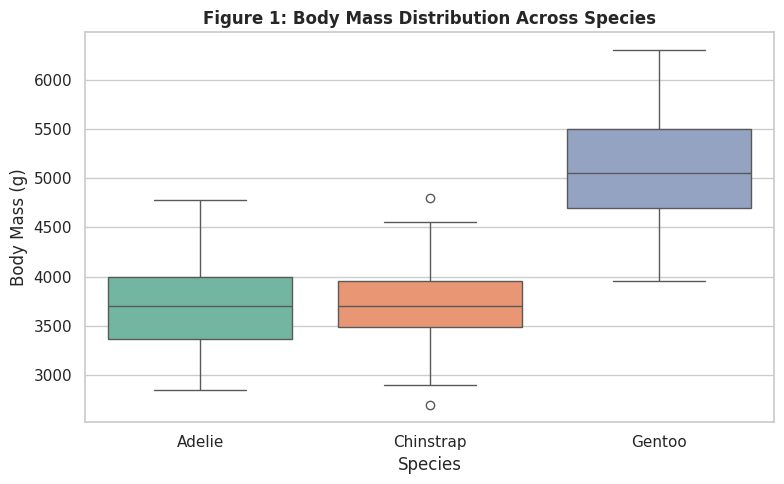

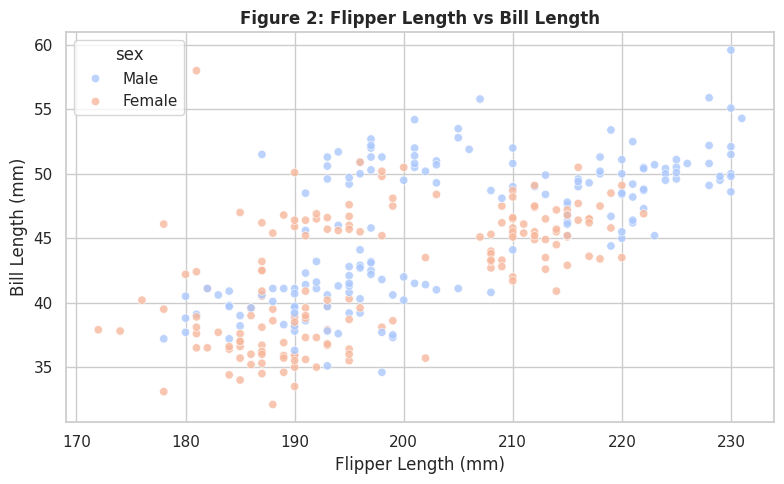

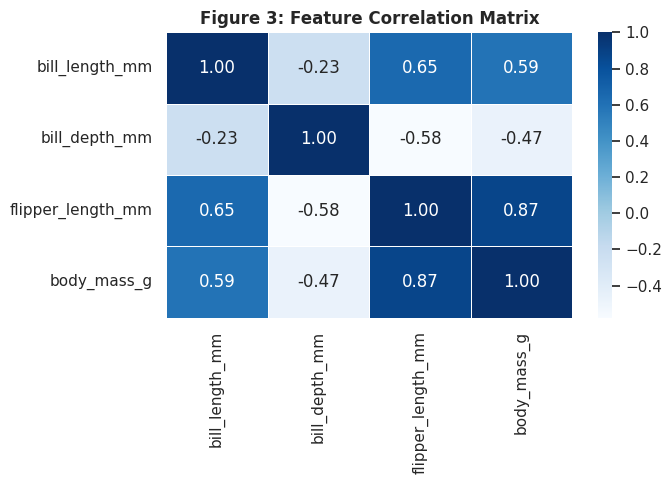

In [10]:
# Set visual style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Figure 1: Distribution of Body Mass by Species
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='species', y='body_mass_g', hue='species', palette='Set2', legend=False)
plt.title('Figure 1: Body Mass Distribution Across Species', fontsize=12, fontweight='bold')
plt.xlabel('Species')
plt.ylabel('Body Mass (g)')
plt.tight_layout()
plt.show()

# Figure 2: Flipper Length vs Bill Length by Sex
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='flipper_length_mm', y='bill_length_mm', hue='sex', palette='coolwarm', alpha=0.8)
plt.title('Figure 2: Flipper Length vs Bill Length', fontsize=12, fontweight='bold')
plt.xlabel('Flipper Length (mm)')
plt.ylabel('Bill Length (mm)')
plt.tight_layout()
plt.show()

# Figure 3: Correlation Heatmap
plt.figure(figsize=(7, 5))
num_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
corr = df[num_cols].corr()
sns.heatmap(data=corr, annot=True, cmap='Blues', fmt='.2f', linewidths=0.5)
plt.title('Figure 3: Feature Correlation Matrix', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### **3.1 Descriptive Summary**

Gentoo species exhibit significantly higher body mass and flipper length compared to Adelie and Chinstrap.

Bill Length vs. Bill Depth displays a unique clustering behavior when segmented by species (demonstrating Simpson's Paradox).

### **3.2 Visualization Analysis & Key Findings**
Note for Word/DOC File: Right-click on the 3 charts generated in Colab, save them as images, and paste them right under these headings in your Word file!

**Figure 1:** Body Mass Distribution Across Species (Box Plot)
Observation: Gentoo penguins have a distinct, non-overlapping higher body mass distribution (range: 4,000g - 6,000g) compared to Adelie and Chinstrap species (range: 2,700g - 4,800g).

**Insight:** Body mass is the most strong physical differentiator for classifying Gentoo penguins from other species.

**Figure 2:** Flipper Length vs. Bill Length Segmented by Gender (Scatter Plot)
Observation: There is a positive linear relationship between flipper length and bill length. Additionally, within every species, male penguins consistently display higher flipper and bill dimensions than females.

**Insight:** Physical size dimensions show strong sexual dimorphism across all three species.

**Figure 3:** Feature Correlation Heatmap (Matrix)
Observation: flipper_length_mm and body_mass_g show a very strong positive correlation (r ≈ 0.87). Conversely, bill_depth_mm exhibits a weaker or slightly negative correlation with other features when evaluated globally.

**Insight:** Flipper length serves as an excellent direct proxy for estimating total body mass in ecological field studies.



### **SECTION 4: Conclusion & Future Scope**
Summary of Deliverables
Successfully acquired an authentic biological dataset.

Cleaned all missing values and handled data structure integrity without loss of critical information.

Generated 3 publication-ready statistical visualizations revealing clear biological relationships.
